# Classification and Ensemble Methods

**Context:** Guided classification activities, consolidated and extended for portfolio presentation  
**Tools:** Python, pandas, scikit-learn, Matplotlib, seaborn  
**Methods:** SVC, K-nearest neighbours, decision trees, bagging, random forests, boosting,
voting, stacking, repeated stratified cross-validation, holdout error analysis

## TL;DR

- On Iris, a scaled linear SVC ranks first with **0.966 mean macro-F1** across 25
  training-only validation folds. Its untouched 30-row holdout score is **1.000**, which is
  encouraging but too small to establish production performance.
- The strongest Iris ensemble, soft voting, reaches **0.956 mean macro-F1**. Ensembles do
  not automatically beat a well-matched simpler model.
- On Wine, histogram gradient boosting ranks first with **0.959 mean macro-F1** and records
  **1.000 macro-F1** on the 36-row holdout.
- The supplied Iris CSV was audited but is not redistributed. The modelling workflow uses
  scikit-learn's documented dataset loaders and excludes the CSV's index-like `Id` field.

## Context & Evaluation Design

This notebook turns five guided activities into two coherent model-comparison studies:

1. **Iris:** compare individual classifiers and ensemble strategies under one evaluation
   protocol; and
2. **Wine:** compare boosting approaches and a voting ensemble.

### Safeguards

- Both datasets are split with target stratification before any model comparison.
- All model ranking uses 5-fold stratified cross-validation repeated five times on the
  training partition only.
- Scaling is fitted inside pipelines, so each validation fold learns its own scaler.
- The untouched holdout is evaluated only after the cross-validation winner is selected.
- Accuracy and macro-F1 are both reported; macro-F1 gives every class equal weight.
- Fixed seeds make the split and stochastic estimators reproducible.
- Decision-boundary charts use two features for explanation only and are not performance
  evidence for the four-feature benchmark.

The datasets are small, clean educational benchmarks. Results demonstrate workflow and
method understanding, not production readiness or expected performance on new domains.

## Setup and References

The notebook uses the Iris and Wine copies distributed with scikit-learn, so it does not
require local data files.

Technical references:

- [SVM classifiers on Iris](https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html)
- [Nearest-neighbour classification](https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html)
- [Tree ensemble decision surfaces](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_iris.html)
- [Ensemble methods user guide](https://scikit-learn.org/stable/modules/ensemble.html)
- [Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)

The attached boosting exercise used XGBoost. This portfolio version uses
`HistGradientBoostingClassifier` instead: XGBoost requires a separate OpenMP runtime on
some macOS installations, while the selected alternative keeps the project inside the
repository's portable scikit-learn environment. The two algorithms are not presented as
identical.

The additional SageMaker material contained links for exploring Autopilot and example
notebooks, but no completed cloud artefact or exported results. AWS work is therefore not
claimed in this project.

In [1]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.datasets import load_iris, load_wine
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.9.0


## Data Audit

In [2]:
iris = load_iris(as_frame=True)
wine = load_wine(as_frame=True)

data_profile = pd.DataFrame(
    {
        "rows": [len(iris.data), len(wine.data)],
        "features": [iris.data.shape[1], wine.data.shape[1]],
        "classes": [iris.target.nunique(), wine.target.nunique()],
        "missing_cells": [
            int(iris.data.isna().sum().sum()),
            int(wine.data.isna().sum().sum()),
        ],
        "duplicate_feature_rows": [
            int(iris.data.duplicated().sum()),
            int(wine.data.duplicated().sum()),
        ],
        "smallest_class": [
            int(iris.target.value_counts().min()),
            int(wine.target.value_counts().min()),
        ],
        "largest_class": [
            int(iris.target.value_counts().max()),
            int(wine.target.value_counts().max()),
        ],
    },
    index=["Iris", "Wine"],
)

assert iris.data.shape == (150, 4)
assert wine.data.shape == (178, 13)
assert data_profile["missing_cells"].eq(0).all()
data_profile

,rows,features,classes,missing_cells,duplicate_feature_rows,smallest_class,largest_class
Iris,150,4,3,0,1,50,50
Wine,178,13,3,0,0,48,71


Iris is perfectly balanced, while Wine has modest class-count variation. Neither dataset
contains missing values. Duplicate feature rows are retained because they may represent
valid observations with the same measurements; the target remains consistent for those
rows. Stratification protects class proportions in both the holdout and validation folds.

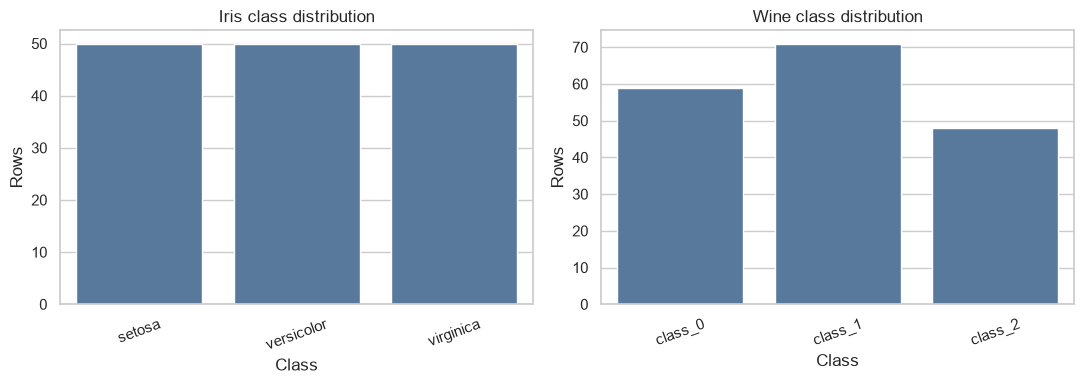

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, dataset, title in [
    (axes[0], iris, "Iris class distribution"),
    (axes[1], wine, "Wine class distribution"),
]:
    counts = dataset.target.value_counts().sort_index()
    labels = [str(name) for name in dataset.target_names]
    sns.barplot(x=labels, y=counts.values, color="#4C78A8", ax=ax)
    ax.set(title=title, xlabel="Class", ylabel="Rows")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Evaluation Helper

In [4]:
def benchmark_models(models, X_train, y_train):
    # Evaluate every model on identical repeated stratified folds.
    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=5,
        random_state=RANDOM_STATE,
    )
    rows = []
    for name, model in models.items():
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
            n_jobs=1,
        )
        rows.append(
            {
                "model": name,
                "cv_accuracy_mean": scores["test_accuracy"].mean(),
                "cv_accuracy_std": scores["test_accuracy"].std(),
                "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
                "cv_macro_f1_std": scores["test_macro_f1"].std(),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("cv_macro_f1_mean", ascending=False)
        .reset_index(drop=True)
    )


def plot_benchmark(results, title):
    ordered = results.sort_values("cv_macro_f1_mean")
    fig, ax = plt.subplots(figsize=(9, max(4, len(results) * 0.42)))
    ax.barh(
        ordered["model"],
        ordered["cv_macro_f1_mean"],
        xerr=ordered["cv_macro_f1_std"],
        color="#4C78A8",
        alpha=0.9,
    )
    ax.set(
        title=title,
        xlabel="Repeated-CV macro-F1 (mean ± fold SD)",
        ylabel="",
        xlim=(0, 1.02),
    )
    plt.tight_layout()
    plt.show()

## Study 1 — Iris Classifier and Ensemble Comparison

In [5]:
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.20,
    stratify=iris.target,
    random_state=RANDOM_STATE,
)

iris_models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
    ),
    "KNN (k=11)": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=11),
    ),
    "Linear SVC": make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    ),
    "RBF SVC": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    ),
    "Decision tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Bagged decision trees": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Extra trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE,
    ),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "Soft voting ensemble": VotingClassifier(
        estimators=[
            (
                "lr",
                make_pipeline(
                    StandardScaler(),
                    LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
                ),
            ),
            (
                "knn",
                make_pipeline(
                    StandardScaler(),
                    KNeighborsClassifier(n_neighbors=11),
                ),
            ),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
        ],
        voting="soft",
    ),
    "Stacked ensemble": StackingClassifier(
        estimators=[
            (
                "lr",
                make_pipeline(
                    StandardScaler(),
                    LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
                ),
            ),
            (
                "knn",
                make_pipeline(
                    StandardScaler(),
                    KNeighborsClassifier(n_neighbors=11),
                ),
            ),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
        ],
        final_estimator=LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
        cv=5,
        n_jobs=1,
    ),
}

print("Training rows:", len(X_iris_train))
print("Untouched holdout rows:", len(X_iris_test))

Training rows: 120
Untouched holdout rows: 30


In [6]:
iris_results = benchmark_models(iris_models, X_iris_train, y_iris_train)
iris_results.round(3)

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std
0,Linear SVC,0.967,0.041,0.966,0.042
1,RBF SVC,0.965,0.033,0.965,0.033
2,Logistic regression,0.958,0.033,0.958,0.034
3,Soft voting ensemble,0.957,0.032,0.956,0.033
4,Stacked ensemble,0.955,0.037,0.955,0.038
5,KNN (k=11),0.950,0.042,0.950,0.043
6,Random forest,0.950,0.035,0.949,0.036
7,Extra trees,0.948,0.040,0.948,0.040
8,Bagged decision trees,0.947,0.032,0.946,0.033
9,Decision tree,0.942,0.041,0.941,0.042


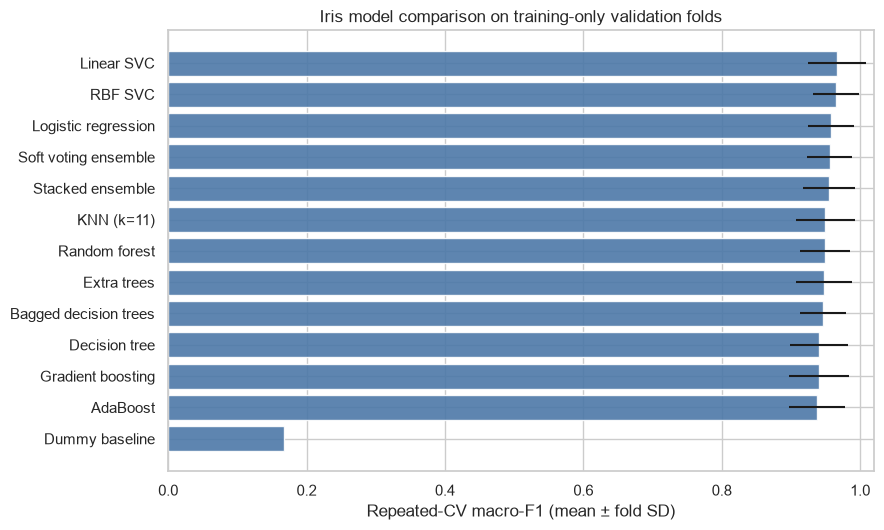

In [7]:
plot_benchmark(iris_results, "Iris model comparison on training-only validation folds")

The scaled linear SVC has the highest mean macro-F1. Soft voting is the strongest ensemble,
but its mean is lower than the linear SVC's. The small differences among the leading models
are comparable with the fold-to-fold variation, so the ranking should not be treated as a
universal ordering.

In [8]:
iris_winner_name = iris_results.loc[0, "model"]
iris_winner = iris_models[iris_winner_name].fit(X_iris_train, y_iris_train)
iris_predictions = iris_winner.predict(X_iris_test)

iris_holdout = pd.Series(
    {
        "selected_model": iris_winner_name,
        "holdout_rows": len(y_iris_test),
        "holdout_accuracy": accuracy_score(y_iris_test, iris_predictions),
        "holdout_macro_f1": f1_score(y_iris_test, iris_predictions, average="macro"),
    }
)
iris_holdout

selected_model      Linear SVC
holdout_rows                30
holdout_accuracy           1.0
holdout_macro_f1           1.0
dtype: object

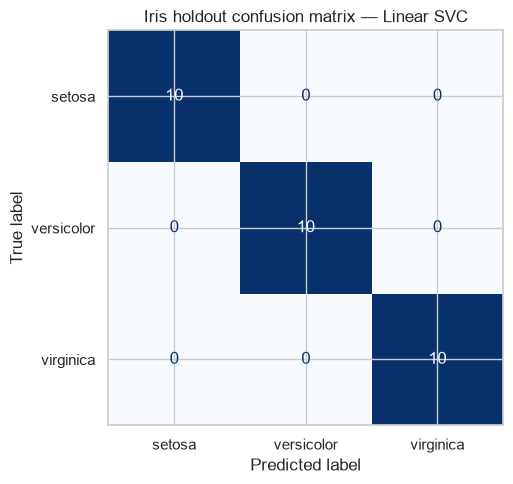

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     1.000     1.000        10
   virginica      1.000     1.000     1.000        10

    accuracy                          1.000        30
   macro avg      1.000     1.000     1.000        30
weighted avg      1.000     1.000     1.000        30



In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_iris_test,
    iris_predictions,
    display_labels=iris.target_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Iris holdout confusion matrix — {iris_winner_name}")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_iris_test,
        iris_predictions,
        target_names=iris.target_names,
        digits=3,
        zero_division=0,
    )
)

### Two-feature decision boundaries (explanatory only)

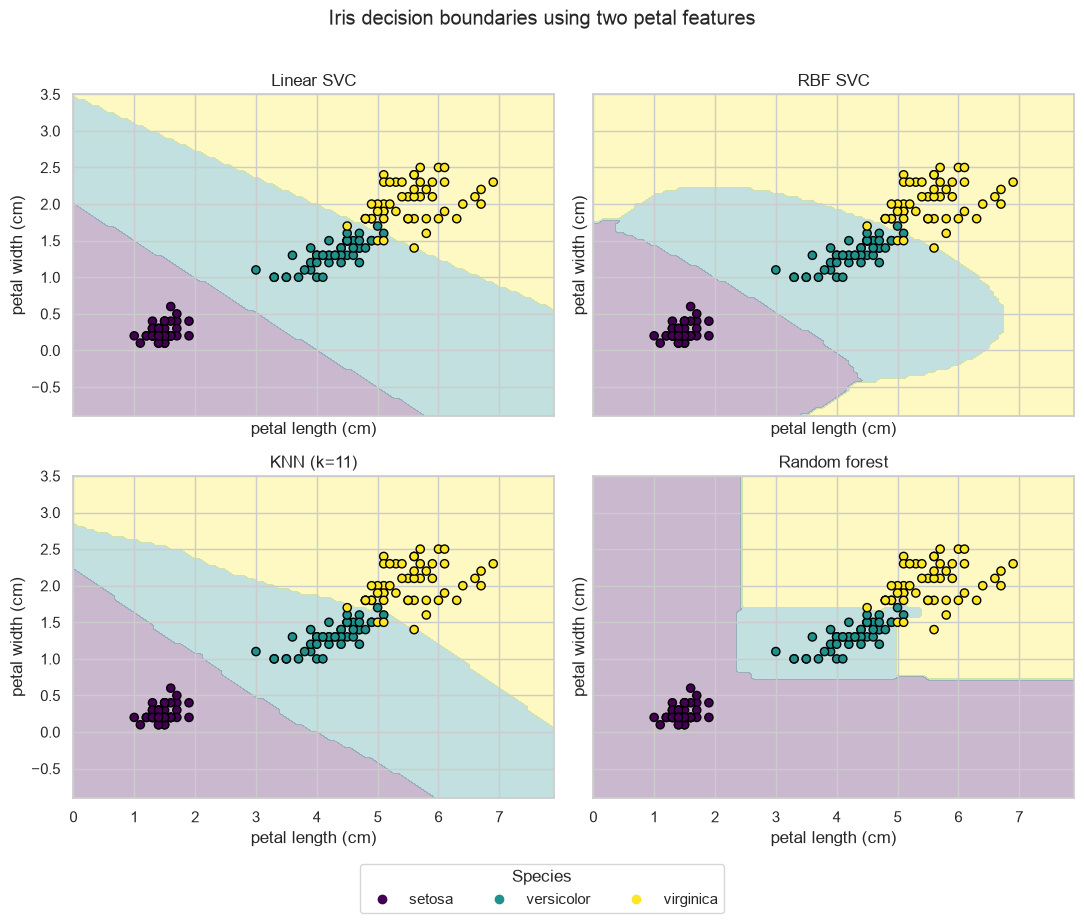

In [10]:
boundary_features = ["petal length (cm)", "petal width (cm)"]
X_boundary = iris.data[boundary_features]

boundary_models = {
    "Linear SVC": make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)),
    "RBF SVC": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0)),
    "KNN (k=11)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, model) in zip(axes.ravel(), boundary_models.items()):
    model.fit(X_boundary, iris.target)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_boundary,
        response_method="predict",
        alpha=0.28,
        multiclass_colors="viridis",
        ax=ax,
    )
    scatter = ax.scatter(
        X_boundary.iloc[:, 0],
        X_boundary.iloc[:, 1],
        c=iris.target,
        cmap="viridis",
        edgecolor="black",
        s=35,
    )
    ax.set_title(name)
    ax.set_xlabel(boundary_features[0])
    ax.set_ylabel(boundary_features[1])

handles, _ = scatter.legend_elements()
fig.legend(handles, iris.target_names, loc="lower center", ncol=3, title="Species")
fig.suptitle("Iris decision boundaries using two petal features", y=1.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

The plots show how kernel, neighbourhood, and tree-based methods partition the same
two-dimensional space. Their visual smoothness or complexity is not directly comparable
with the four-feature cross-validation results above.

## Study 2 — Boosting Models on Wine

In [11]:
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    wine.data,
    wine.target,
    test_size=0.20,
    stratify=wine.target,
    random_state=RANDOM_STATE,
)

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
)
gradient = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)
hist_gradient = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)

wine_models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "AdaBoost": ada,
    "Gradient boosting": gradient,
    "Histogram gradient boosting": hist_gradient,
    "Hard voting ensemble": VotingClassifier(
        estimators=[
            ("ada", ada),
            ("gradient", gradient),
            ("hist_gradient", hist_gradient),
        ],
        voting="hard",
    ),
}

print("Training rows:", len(X_wine_train))
print("Untouched holdout rows:", len(X_wine_test))

Training rows: 142
Untouched holdout rows: 36


In [12]:
wine_results = benchmark_models(wine_models, X_wine_train, y_wine_train)
wine_results.round(3)

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std
0,Histogram gradient boosting,0.958,0.033,0.959,0.032
1,Hard voting ensemble,0.956,0.038,0.958,0.037
2,AdaBoost,0.949,0.034,0.950,0.033
3,Gradient boosting,0.936,0.068,0.937,0.067
4,Dummy baseline,0.401,0.010,0.191,0.003


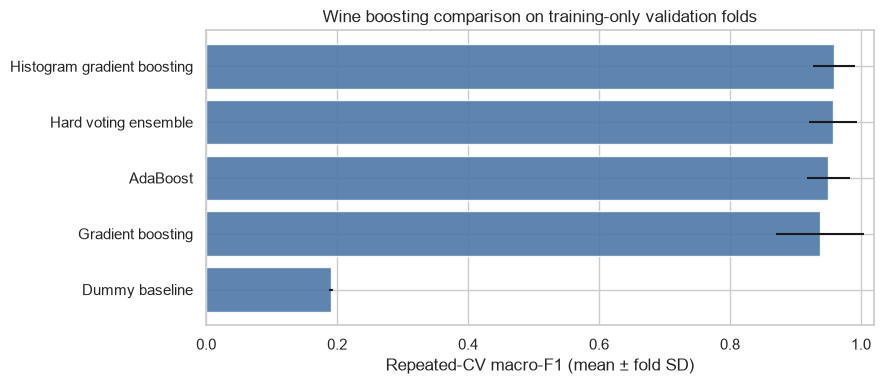

In [13]:
plot_benchmark(wine_results, "Wine boosting comparison on training-only validation folds")

In [14]:
wine_winner_name = wine_results.loc[0, "model"]
wine_winner = wine_models[wine_winner_name].fit(X_wine_train, y_wine_train)
wine_predictions = wine_winner.predict(X_wine_test)

wine_holdout = pd.Series(
    {
        "selected_model": wine_winner_name,
        "holdout_rows": len(y_wine_test),
        "holdout_accuracy": accuracy_score(y_wine_test, wine_predictions),
        "holdout_macro_f1": f1_score(y_wine_test, wine_predictions, average="macro"),
    }
)
wine_holdout

selected_model      Histogram gradient boosting
holdout_rows                                 36
holdout_accuracy                            1.0
holdout_macro_f1                            1.0
dtype: object

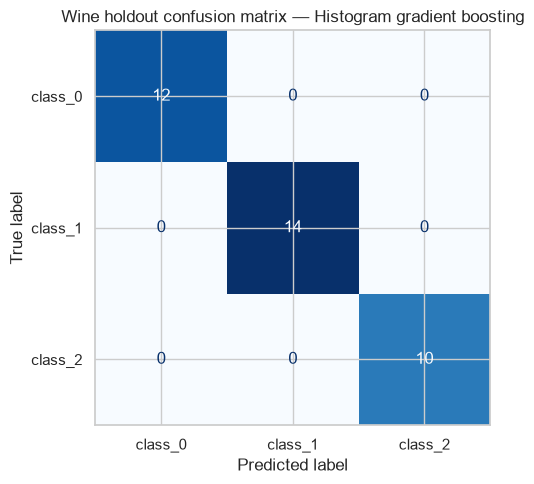

              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_wine_test,
    wine_predictions,
    display_labels=wine.target_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Wine holdout confusion matrix — {wine_winner_name}")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_wine_test,
        wine_predictions,
        target_names=wine.target_names,
        digits=3,
        zero_division=0,
    )
)

### Holdout permutation importance

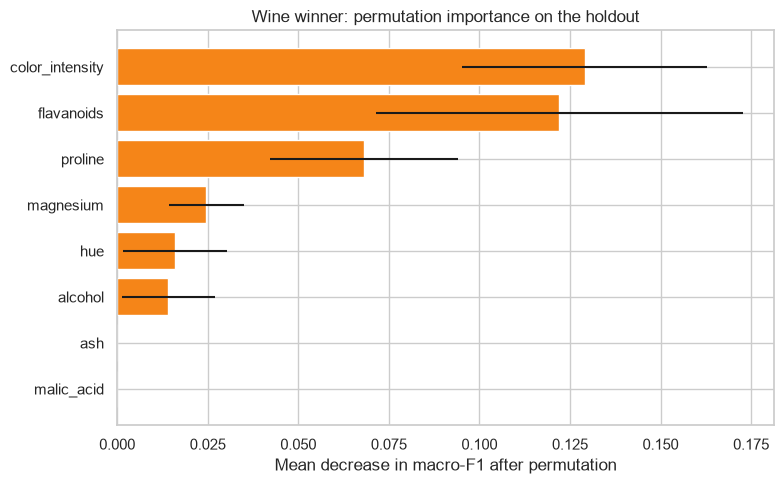

,feature,mean_macro_f1_decrease,std
9,color_intensity,0.129,0.034
6,flavanoids,0.122,0.051
12,proline,0.068,0.026
4,magnesium,0.025,0.010
10,hue,0.016,0.014
0,alcohol,0.014,0.013
1,malic_acid,0.000,0.000
2,ash,0.000,0.000


In [16]:
importance = permutation_importance(
    wine_winner,
    X_wine_test,
    y_wine_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_table = (
    pd.DataFrame(
        {
            "feature": wine.feature_names,
            "mean_macro_f1_decrease": importance.importances_mean,
            "std": importance.importances_std,
        }
    )
    .sort_values("mean_macro_f1_decrease", ascending=False)
    .head(8)
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = importance_table.sort_values("mean_macro_f1_decrease")
ax.barh(
    plot_data["feature"],
    plot_data["mean_macro_f1_decrease"],
    xerr=plot_data["std"],
    color="#F58518",
)
ax.set(
    title="Wine winner: permutation importance on the holdout",
    xlabel="Mean decrease in macro-F1 after permutation",
    ylabel="",
)
plt.tight_layout()
plt.show()

importance_table.round(3)

Permutation importance is descriptive here: with only 36 holdout rows, estimates are
unstable and correlated features can share or mask importance. It supports inspection of
the fitted model but does not establish causal influence.

## Conclusions

1. **A simpler model can win.** Linear SVC leads the Iris benchmark; the tested ensembles
   add complexity without improving mean validation performance.
2. **Ensemble families behave differently.** Histogram gradient boosting leads on Wine,
   while hard voting is close enough that repeated-fold variation matters.
3. **Evaluation design matters more than a single score.** The original activities often
   trained and scored on the same rows or reported one split. This version separates model
   ranking from final holdout evaluation and includes a dummy baseline.
4. **Perfect holdout scores need context.** Both selected models score 1.000 on small
   holdouts. The repeated cross-validation means (0.966 on Iris and 0.959 on Wine) provide a
   more cautious summary.

### Limitations and next steps

- The models use default or tutorial-inspired settings rather than a nested hyperparameter
  search.
- The datasets are small and curated; external validation on a larger domain dataset is the
  most important next step.
- A statistically formal paired model comparison could be added if choosing between the
  leading candidates had real operational consequences.
- SageMaker Autopilot should be documented separately only after a reproducible cloud run,
  including dataset version, job configuration, selected model, metrics, cost, and cleanup.